In [2]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

## Classification Problems
<img align="left" src="./images/C1_W3_Classification.png"     style=" width:380px; padding: 10px; " > Examples of classification problems are things like: identifying email as Spam or Not Spam or determining if a tumor is malignant or benign. In particular, these are examples of *binary* classification where there are two possible outcomes.  Outcomes can be  described in pairs of 'positive'/'negative' such as 'yes'/'no, 'true'/'false' or '1'/'0'. 

Plots of classification data sets often use symbols to indicate the outcome of an example. In the plots below, 'X' is used to represent the positive values while 'O' represents negative outcomes. 

In [3]:
x_train = np.array([0., 1, 2, 3, 4, 5])
y_train = np.array([0,  0, 0, 1, 1, 1])
X_train2 = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_train2 = np.array([0, 0, 0, 1, 1, 1])

[False False False  True  True  True]
[ True  True  True False False False]


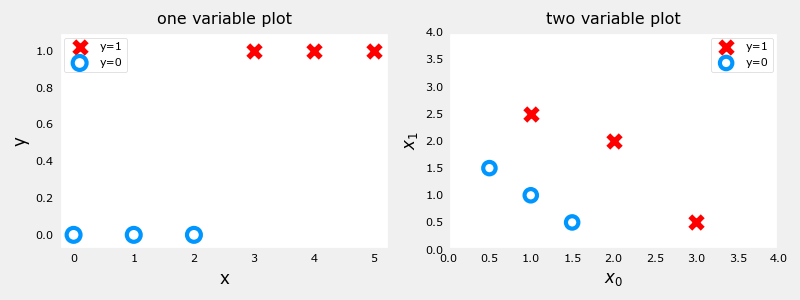

In [4]:
pos = y_train == 1
neg = y_train == 0
print(pos)
print(neg)

def plot_data(X, y, ax, pos_label="y=1", neg_label="y=0", s=80, loc='best' ):
    """ plots logistic data with two axis """
    # Find Indices of Positive and Negative Examples
    pos = y == 1
    neg = y == 0
    pos = pos.reshape(-1,)  #work with 1D or 1D y vectors
    neg = neg.reshape(-1,)

    # Plot examples
    ax.scatter(X[pos, 0], X[pos, 1], marker='x', s=s, c = 'red', label=pos_label)
    ax.scatter(X[neg, 0], X[neg, 1], marker='o', s=s, label=neg_label, facecolors='none', edgecolors=dlblue, lw=3)
    ax.legend(loc=loc)

    ax.figure.canvas.toolbar_visible = False
    ax.figure.canvas.header_visible = False
    ax.figure.canvas.footer_visible = False

dlc = dict(dlblue = '#0096ff', dlorange = '#FF9300', dldarkred='#C00000', dlmagenta='#FF40FF', dlpurple='#7030A0')
dlblue = '#0096ff'; dlorange = '#FF9300'; dldarkred='#C00000'; dlmagenta='#FF40FF'; dlpurple='#7030A0'
dlcolors = [dlblue, dlorange, dldarkred, dlmagenta, dlpurple]

fig,ax = plt.subplots(1,2,figsize=(8,3))
#plot 1, single variable
ax[0].scatter(x_train[pos], y_train[pos], marker='x', s=80, c = 'red', label="y=1")
ax[0].scatter(x_train[neg], y_train[neg], marker='o', s=100, label="y=0", facecolors='none', 
              edgecolors=dlc["dlblue"],lw=3)

ax[0].set_ylim(-0.08,1.1)
ax[0].set_ylabel('y', fontsize=12)
ax[0].set_xlabel('x', fontsize=12)
ax[0].set_title('one variable plot')
ax[0].legend()

#plot 2, two variables
plot_data(X_train2, y_train2, ax[1])
ax[1].axis([0, 4, 0, 4])
ax[1].set_ylabel('$x_1$', fontsize=12)
ax[1].set_xlabel('$x_0$', fontsize=12)
ax[1].set_title('two variable plot')
ax[1].legend()
plt.tight_layout()
plt.show()


Note in the plots above:
- In the single variable plot, positive results are shown both a red 'X's and as y=1. Negative results are blue 'O's and are located at y=0.
   - Recall in the case of linear regression, y would not have been limited to two values but could have been any value.
- In the two-variable plot, the y axis is not available.  Positive results are shown as red 'X's, while negative results use the blue 'O' symbol.
    - Recall in the case of linear regression with multiple variables, y would not have been limited to two values and a similar plot would have been three-dimensional.

## Linear Regression approach
In the previous week, you applied linear regression to build a prediction model. Let's try that approach here using the simple example that was described in the lecture. The model will predict if a tumor is benign or malignant based on tumor size.  Try the following:
- Click on 'Run Linear Regression' to find the best linear regression model for the given data.
    - Note the resulting linear model does **not** match the data well. 
One option to improve the results is to apply a *threshold*. 
- Tick the box on the 'Toggle 0.5 threshold' to show the predictions if a threshold is applied.
    - These predictions look good, the predictions match the data
- *Important*: Now, add further 'malignant' data points on the far right, in the large tumor size range (near 10), and re-run linear regression.
    - Now, the model predicts the larger tumor, but data point at x=3 is being incorrectly predicted!
- to clear/renew the plot, rerun the cell containing the plot command.

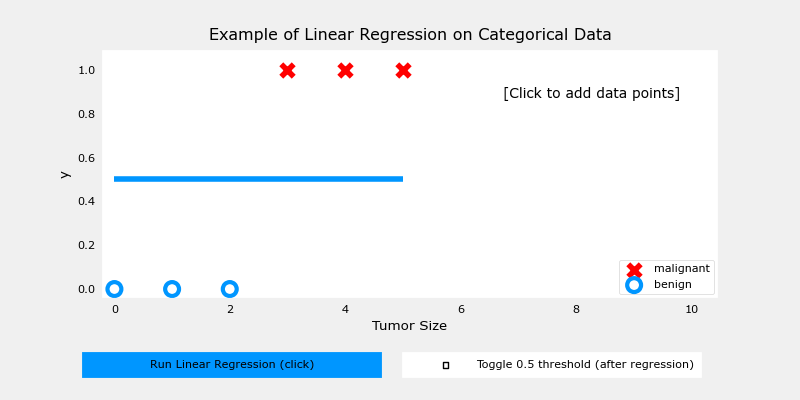

In [6]:
import importlib
from plt_one_addpt_onclick import plt_one_addpt_onclick

w_in = np.zeros(1)
b_in = 0
plt.close('all') 
addpt = plt_one_addpt_onclick( x_train,y_train, w_in, b_in, logistic=False)

# Result after adding outliers on right side

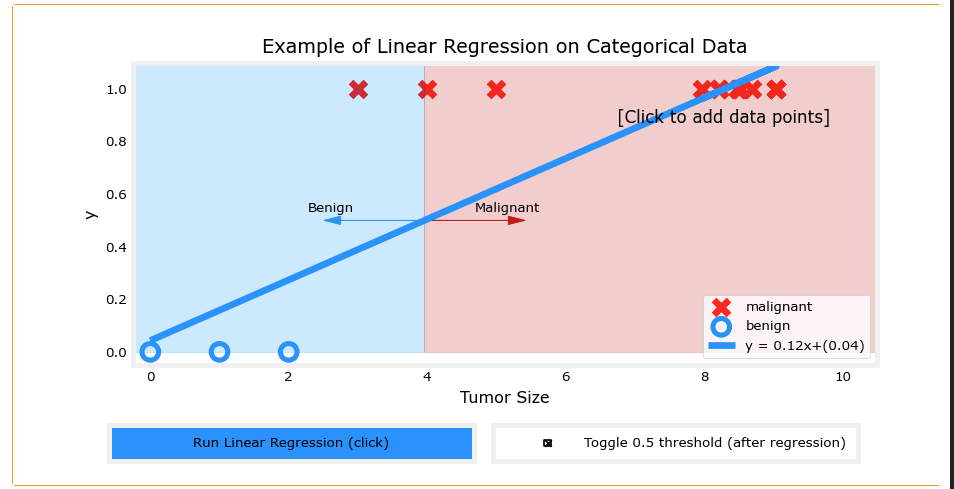
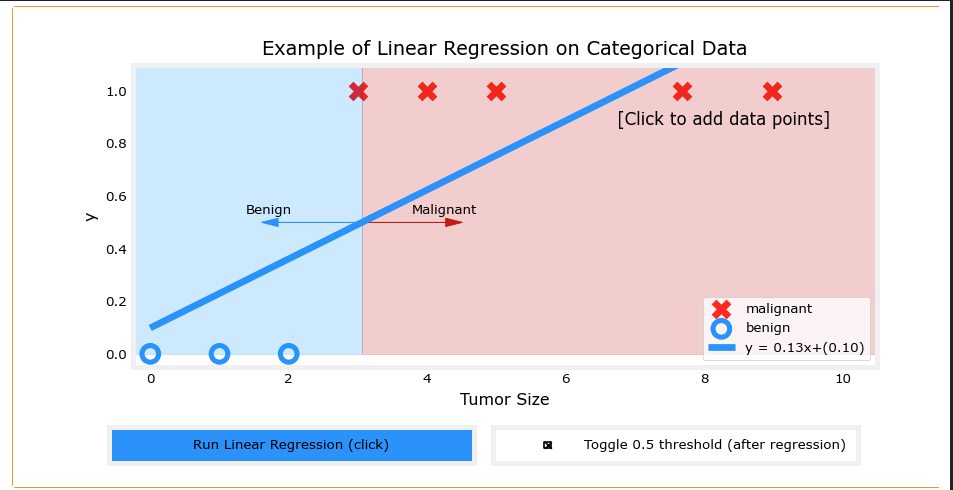

# Why is MSE not used in Logistic Regression?

There are **two complementary answers** to this question.

---

# 1. Statistical Perspective (The Fundamental Reason) ⭐⭐⭐⭐⭐

This is the **actual theoretical reason**.

Logistic Regression assumes that the target labels follow a **Bernoulli Distribution**, unlike Linear Regression which assumes a **Gaussian (Normal) Distribution**.

## Bernoulli Assumption

$$
y \sim \text{Bernoulli}(p)
$$

where

$$
p=\sigma(\mathbf{w}^T\mathbf{x}+b)
$$

The model predicts

$$
P(y=1|x)=p
$$

---

## Maximum Likelihood Estimation (MLE)

For a single Bernoulli random variable,

$$
P(y_i)=p_i^{\,y_i}(1-p_i)^{\,1-y_i}
$$

---

For the complete dataset containing **m independent training examples**, the likelihood is

## Likelihood

$$
L(\mathbf{w},b)
=
\prod_{i=1}^{m}
p_i^{\,y_i}(1-p_i)^{\,1-y_i}
$$

Our goal is to **maximize** this likelihood.

---

## Log-Likelihood

Taking the logarithm converts the product into a summation.

$$
\log L(\mathbf{w},b)
=
\sum_{i=1}^{m}
\left[
y_i\log(p_i)
+
(1-y_i)\log(1-p_i)
\right]
$$

---

## Negative Log-Likelihood (Cross Entropy)

Machine Learning algorithms minimize a loss function.

Therefore, instead of maximizing the log-likelihood, we minimize its negative.

$$
J(\mathbf{w},b)
=
-\frac{1}{m}
\sum_{i=1}^{m}
\left[
y_i\log(p_i)
+
(1-y_i)\log(1-p_i)
\right]
$$

This is exactly the **Binary Cross Entropy Loss**.

---

## Conclusion

**Linear Regression**

- Assumes **Gaussian Distribution**
- MLE naturally derives **Mean Squared Error (MSE)**

**Logistic Regression**

- Assumes **Bernoulli Distribution**
- MLE naturally derives **Binary Cross Entropy (Log Loss)**

This is the **fundamental theoretical justification**.

---

# 2. Optimization Perspective (The Practical Reason) ⭐⭐⭐⭐☆

Suppose we ignore probability theory and use Mean Squared Error.

The prediction is

$$
\hat{y}=\sigma(z)
$$

where

$$
z=\mathbf{w}^T\mathbf{x}+b
$$

Using MSE,

$$
L=
\frac12(\hat{y}-y)^2
$$

Substituting the sigmoid,

$$
L=
\frac12(\sigma(z)-y)^2
$$

This creates two major problems.

---

## (a) Non-Convex Optimization Problem

For Linear Regression,

$$
\hat{y}=\mathbf{w}^T\mathbf{x}+b
$$

Using MSE produces a **convex (bowl-shaped) cost function**.

However,

$$
\hat{y}=\sigma(\mathbf{w}^T\mathbf{x}+b)
$$

Using

$$
\text{MSE}+\text{Sigmoid}
$$

does **not** produce the same favorable optimization landscape.

Optimization becomes more difficult.

---

## (b) Vanishing Gradients

The gradient becomes

$$
\frac{\partial L}{\partial w}
=
(\hat{y}-y)\,
\sigma'(z)\,
x
$$

where

$$
\sigma'(z)
=
\sigma(z)\left(1-\sigma(z)\right)
$$

When

$$
\sigma(z)\approx0
$$

or

$$
\sigma(z)\approx1
$$

then

$$
\sigma'(z)\approx0
$$

Therefore,

$$
\frac{\partial L}{\partial w}\approx0
$$

even when the prediction is completely wrong.

As a result,

- Learning becomes slow.
- Weight updates become tiny.
- Gradient Descent converges slowly.

---

## Cross Entropy Solves This

For Binary Cross Entropy,

the gradient simplifies to

$$
\frac{\partial L}{\partial w}
=
(\hat{y}-y)x
$$

Notice that

$$
\sigma'(z)
$$

is no longer present.

The sigmoid derivative cancels during differentiation.

Therefore,

- Large mistakes produce large gradients.
- Faster learning.
- More stable optimization.

---

# Interview Answer

### Q. Why don't we use MSE in Logistic Regression?

**Answer**

The primary reason is **probabilistic**.

Logistic Regression assumes that the target labels follow a **Bernoulli Distribution**. Applying **Maximum Likelihood Estimation (MLE)** naturally derives the **Binary Cross Entropy (Negative Log-Likelihood)** loss function rather than Mean Squared Error.

From an optimization perspective, using MSE together with the sigmoid function introduces an additional sigmoid derivative into the gradient. This causes very small gradients when predictions are close to 0 or 1, leading to slower learning and a less favorable optimization landscape.

Binary Cross Entropy avoids these issues and is therefore the preferred loss function.

---

# Interview Cheat Sheet

| Question | Answer |
|----------|--------|
| **Why does Linear Regression use MSE?** | MLE with a Gaussian assumption naturally derives Mean Squared Error. |
| **Why does Logistic Regression use Cross Entropy?** | MLE with a Bernoulli assumption naturally derives Binary Cross Entropy (Negative Log-Likelihood). |
| **Can MSE be used for Logistic Regression?** | Yes. It is mathematically valid, but it is generally avoided because it does not correspond to the Bernoulli likelihood and leads to poorer optimization due to vanishing gradients and a less favorable optimization landscape. |

---

# One-Line Summary

| Linear Regression | Logistic Regression |
|-------------------|---------------------|
| Continuous Output | Binary Output |
| Gaussian Distribution | Bernoulli Distribution |
| Maximum Likelihood Estimation | Maximum Likelihood Estimation |
| Mean Squared Error (MSE) | Binary Cross Entropy (Log Loss) |
| Convex Optimization | Convex Negative Log-Likelihood |
| Fast Gradient Descent | Fast & Stable Gradient Descent |